## Bibliotecas e necessários

In [9]:
from sklearn.metrics import f1_score, precision_recall_fscore_support
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
from scipy.stats import norm
import lightgbm as lgb
import xgboost as xgb
import pandas as pd
import numpy as np
from tabpfn import TabPFNClassifier

import os
import json
from pathlib import Path
import torch
import joblib
import warnings
from google import genai
from google.genai import types
from openai import OpenAI

from sklearn.inspection import permutation_importance

import shapiq
import shap

warnings.filterwarnings("ignore")

print("true" if os.getenv("TABPFN_TOKEN") else "False tabpfn")
print("true" if os.getenv("GEMINI_API_KEY") else "False gemini")
print("true" if os.getenv("OPENAI_API_KEY") else "False openai")
print(torch.cuda.is_available())

df = pd.read_parquet('Base_onda_Onda 1_desfecho_obito_variaveis_all.parquet')

true
true
true
True


## Análise Geral

In [ ]:
df.head()

,idade,sexo,scv___1,scv___2,scv___3,scv___4,scv___5,scv___6,sr___1,sr___2,...,vacina,dimero_adm_final_relacao,Hometown_GDP,Hometown_DHI,Hospital_GDP,Hospital_DHI,Academic_status,Accreditation,Source_of_income,obito
index,,,,,,,,,,,,,,,,,,,,,
0,61.0,2.0,1,0,0,0,0,0,0,0,...,0.0,NaN,41476.05,0.758,38670.4,0.81,1.0,0.0,0.0,1.0
1,44.0,2.0,1,0,0,0,0,0,0,0,...,0.0,NaN,38670.40,0.810,38670.4,0.81,1.0,0.0,0.0,0.0
2,75.0,1.0,1,0,0,0,0,0,0,0,...,0.0,27.310000,38670.40,0.810,38670.4,0.81,1.0,0.0,0.0,0.0
5,60.0,1.0,1,0,0,0,0,0,0,0,...,0.0,16.981818,22999.64,0.731,38670.4,0.81,1.0,0.0,0.0,0.0
6,54.0,2.0,0,0,0,0,0,0,1,0,...,0.0,NaN,38670.40,0.810,38670.4,0.81,1.0,0.0,0.0,0.0


In [4]:
print(df[df['obito'] == 1].shape)

(1035, 62)


In [5]:
def IC_95(medidas):
    media = np.mean(medidas)
    erro_padrao = np.std(medidas, ddof=1) / np.sqrt(len(medidas))
    intervalo = norm.ppf(0.975) * erro_padrao  # z-score 95%
    return f"{media:.4f}({intervalo:.4f})"

def IC_95_percentage(medidas):
    media = np.mean(medidas)*100
    erro_padrao = np.std(medidas, ddof=1) / np.sqrt(len(medidas))*100
    intervalo = norm.ppf(0.975) * erro_padrao
    return f"{media:.1f}({intervalo:.1f})"

def evaluateModel(y_true_folds, y_pred_folds, classes, modelo_nome):
    macro_f1s, micro_f1s, precisao_folds, recall_folds, f1_folds = [], [], [], [], []
    
    for y_true, y_pred in zip(y_true_folds, y_pred_folds):
        macro_f1s.append(f1_score(y_true, y_pred, average="macro"))
        micro_f1s.append(f1_score(y_true, y_pred, average="micro"))
        prec, rec, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, average=None, labels=classes, zero_division=0
        )
        precisao_folds.append(prec)
        recall_folds.append(rec)
        f1_folds.append(f1)

    precisao_folds = np.array(precisao_folds)
    recall_folds = np.array(recall_folds)
    f1_folds = np.array(f1_folds)

    resultados = {
        "modelo": modelo_nome,
        "macro_f1": IC_95_percentage(macro_f1s),
        "micro_f1": IC_95_percentage(micro_f1s)
    }

    for i, c in enumerate(classes):
        resultados[f"precisao_{c}"] = IC_95_percentage(precisao_folds[:, i])
        resultados[f"recall_{c}"] = IC_95_percentage(recall_folds[:, i])
        resultados[f"f1_{c}"] = IC_95_percentage(f1_folds[:, i])
    
    return resultados

def trainModels(df, target_col, classificador):
    X = df.drop(columns=[target_col])
    y = df[target_col]
    classes = np.unique(y)

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    y_true_folds, y_pred_folds = [], []

    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        if classificador == "LightGBM":
            modelo = lgb.LGBMClassifier(random_state=7, verbose=-1)
        elif classificador == "XGBoost":
            modelo = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=7)
        elif classificador == "TabPFN":
            modelo = TabPFNClassifier(device='cuda', random_state=7)
        else:
            raise ValueError(f"Classificador '{classificador}' não reconhecido.")

        modelo.fit(X_train, y_train)
        y_pred = modelo.predict(X_test)

        y_true_folds.append(y_test)
        y_pred_folds.append(y_pred)

    resultados = evaluateModel(y_true_folds, y_pred_folds, classes, classificador)
    return resultados



In [7]:
classificadores = ["LightGBM", "XGBoost", "TabPFN"]

resultados_gerais = []

for metodo in classificadores:
    print(f"Treinando e avaliando: {metodo}...")
    resultados = trainModels(df, target_col='obito', classificador=metodo)
    resultados_gerais.append(resultados)

df_resultados = pd.DataFrame(resultados_gerais)
df_resultados.to_csv('resultados_modelos.csv', index=False)

print("\nResultados finais:")
print(df_resultados)

Treinando e avaliando: LightGBM...


Treinando e avaliando: XGBoost...
Treinando e avaliando: TabPFN...

Resultados finais:
     modelo   macro_f1   micro_f1 precisao_0.0 recall_0.0     f1_0.0  \
0  LightGBM  73.4(2.0)  87.1(0.9)    89.9(0.7)  95.3(0.7)  92.5(0.5)   
1   XGBoost  73.8(2.0)  87.3(0.8)    90.0(0.7)  95.4(0.4)  92.6(0.4)   
2    TabPFN  75.5(2.1)  88.2(0.8)    90.4(0.7)  96.1(0.5)  93.2(0.5)   

  precisao_1.0 recall_1.0     f1_1.0  
0    66.2(3.8)  46.1(3.7)  54.3(3.5)  
1    67.0(2.8)  46.7(4.3)  55.0(3.7)  
2    71.4(3.3)  48.7(4.4)  57.8(3.7)  


## Shap Geral

### Analise global

In [ ]:
DF_PATH = "/df_total.parquet"
SHAP_BASE_DIR = "/shap"
MODELS_DIR = "/models_tabpfn"
METRICS_DIR = "/metrics_tabpfn"

N_SPLITS = 10
RANDOM_STATE = 42

N_EXPLAIN = 200          # <<<<<<<<<< gera summary plot
TABPFN_SAMPLE_TRAIN = 300
TABPFN_BUDGET = 64
TOP_K_FEATURES = 10
FORCE_CUDA_DEVICE = "cuda:0"
SAVE_MODELS = True

os.makedirs(SHAP_BASE_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(METRICS_DIR, exist_ok=True)

# -------------------------
# GPU tuning
# -------------------------
device = torch.device(FORCE_CUDA_DEVICE if torch.cuda.is_available() else "cpu")
print("Usando device:", device)

# -------------------------
# Utils
# -------------------------
def ensure_dir(path):
    os.makedirs(path, exist_ok=True)
    return path

def save_fig_from_axes(outfile):
    plt.gcf().savefig(outfile, dpi=300, bbox_inches="tight")
    plt.close()

# ---------------------------------------------------------
# FUNÇÃO PARA SUMMARY PLOT (beeswarm) IGUAL AO DA IMAGEM
# ---------------------------------------------------------
def shap_summary_plot(shap_values, X, feature_names, outfile=None):

    plt.figure(figsize=(8, 12))

    n_features = shap_values.shape[1]

    # features invertidas (igual ao SHAP original)
    for i in range(n_features):
        sv = shap_values[:, i]        # SHAP values
        fv = X[:, i]                  # feature values para cor

        # normalização para cor
        if fv.max() != fv.min():
            norm = (fv - fv.min()) / (fv.max() - fv.min())
        else:
            norm = np.zeros_like(fv)

        colors = plt.cm.coolwarm(norm)

        # jitter vertical para aparência "beeswarm"
        jitter = (np.random.rand(len(sv)) - 0.5) * 0.2

        plt.scatter(
            sv,
            np.full_like(sv, n_features - i) + jitter,
            s=12, color=colors, alpha=0.8
        )

    plt.axvline(0, color="black", linewidth=1)

    plt.yticks(range(1, n_features + 1), feature_names[::-1])
    plt.xlabel("SHAP value (impact on model output)")
    plt.title("SHAP Summary Plot (TabPFN + SHAPIQ)")
    plt.tight_layout()

    if outfile:
        plt.savefig(outfile, dpi=300, bbox_inches="tight")
        plt.close()
    else:
        plt.show()


# -------------------------
# Função principal do fold
# -------------------------
def run_tabpfn_on_fold(X_train_np, y_train_np, X_test_np, y_test_np, feature_names, fold_idx):

    fold_dir = ensure_dir(os.path.join(SHAP_BASE_DIR, f"fold_{fold_idx}", "TabPFN"))
    model_path = os.path.join(MODELS_DIR, f"tabpfn_fold_{fold_idx}.joblib")
    metrics_path = os.path.join(METRICS_DIR, f"metrics_fold_{fold_idx}.csv")

    cache_path_template = os.path.join(
        fold_dir,
        "tabpfn_values_explainer_fold{fold}_k{K}.npz"
    )

    print(f"\n=== Fold {fold_idx} — treinamento TabPFN ===")

    # modelo principal
    model_main = TabPFNClassifier(device=device, random_state=RANDOM_STATE)
    model_main.fit(X_train_np, y_train_np)

    # métricas
    y_pred = model_main.predict(X_test_np)

    from sklearn.metrics import precision_recall_fscore_support, f1_score
    prec, rec, f1_vals, _ = precision_recall_fscore_support(
        y_test_np, y_pred, average=None, zero_division=0
    )

    macro = f1_score(y_test_np, y_pred, average="macro")
    micro = f1_score(y_test_np, y_pred, average="micro")

    metrics = {"fold": fold_idx, "macro_f1": macro, "micro_f1": micro}

    uniques = np.unique(np.concatenate([y_train_np, y_test_np]))
    for i, cls in enumerate(uniques):
        metrics[f"precisao_{cls}"] = float(prec[i])
        metrics[f"recall_{cls}"] = float(rec[i])
        metrics[f"f1_{cls}"] = float(f1_vals[i])

    pd.DataFrame([metrics]).to_csv(metrics_path, index=False)
    print("Métricas salvas em:", metrics_path)

    if SAVE_MODELS:
        joblib.dump(model_main, model_path)
        print("Modelo salvo em:", model_path)

    # -------------------------
    # Seleção das top features
    # -------------------------
    n_train_sample = min(TABPFN_SAMPLE_TRAIN, X_train_np.shape[0])
    rng = np.random.RandomState(RANDOM_STATE + fold_idx)
    sample_idx = rng.choice(X_train_np.shape[0], size=n_train_sample, replace=False)

    x_small = X_train_np[sample_idx]
    y_small = y_train_np[sample_idx]

    try:
        pi = permutation_importance(
            model_main, X_test_np, y_test_np,
            n_repeats=3, random_state=RANDOM_STATE, n_jobs=1
        )
        important_idx = np.argsort(pi.importances_mean)[::-1][:TOP_K_FEATURES]
    except Exception:
        important_idx = np.argsort(np.var(x_small, axis=0))[::-1][:TOP_K_FEATURES]

    # reduz dimensões
    x_small_sel = x_small[:, important_idx]
    X_test_sel = X_test_np[:, important_idx]
    feature_names_sel = [feature_names[i] for i in important_idx]

    # -------------------------
    # Treina modelo pequeno (apenas top features)
    # -------------------------
    model_small = TabPFNClassifier(device=device, random_state=RANDOM_STATE)
    model_small.fit(x_small_sel, y_small)

    try:
        avg_pred = float(model_small.predict(x_small_sel).mean())
    except:
        avg_pred = 0.5

    # -------------------------
    # SHAPIQ
    # -------------------------
    cache_path = cache_path_template.format(fold=fold_idx, K=len(important_idx))

    explainer = shapiq.Explainer(
        model=model_small,
        data=x_small_sel,
        labels=y_small,
        index="SV",
        max_order=1,
        empty_prediction=avg_pred,
    )

    if not Path(cache_path).exists():
        print("Criando cache SHAPIQ...")
        explainer.imputer.fit(X_test_sel[0].reshape(1, -1))
        explainer.imputer.precompute()
        explainer.imputer.save_values(cache_path)
        print("Cache salvo em:", cache_path)
    else:
        explainer.imputer.load_values(cache_path)
        print("Cache carregado:", cache_path)

    # -------------------------
    # Explicar vários exemplos (para summary plot)
    # -------------------------
    n_explain = min(N_EXPLAIN, X_test_sel.shape[0])
    all_shap_values = []

    for i in range(n_explain):
        x_explain = X_test_sel[i].reshape(1, -1)
        shapley_values = explainer.explain(x_explain, budget=TABPFN_BUDGET)

        vals = shapley_values.values
        # normaliza para 2D
        if vals.ndim == 1:
            vals = vals.reshape(1, -1)

        # caso comum: shapiq retornou K+1 (valor base incluso) -> remover a coluna extra
        if vals.shape[1] == X_test_sel.shape[1] + 1:
            # assumimos que a coluna extra é o último elemento; removemos
            vals = vals[:, :X_test_sel.shape[1]]
        elif vals.shape[1] != X_test_sel.shape[1]:
            # aviso informativo e tentativa de ajuste defensivo
            print(f"AVISO: dimensão SHAPIQ inesperada em fold {fold_idx}, exemplo {i}:",
                  f"vals.shape={vals.shape}, X_test_sel.shape[1]={X_test_sel.shape[1]}")
            # se maior, truncar; se menor, preencher com zeros (defensivo)
            if vals.shape[1] > X_test_sel.shape[1]:
                vals = vals[:, :X_test_sel.shape[1]]
            else:
                pad = np.zeros((vals.shape[0], X_test_sel.shape[1] - vals.shape[1]))
                vals = np.concatenate([vals, pad], axis=1)

        all_shap_values.append(vals.flatten())

    all_shap_values = np.array(all_shap_values)
    np.save(os.path.join(fold_dir, "all_shap_values.npy"), all_shap_values)

    # -------------------------
    # SUMMARY PLOT
    # -------------------------
    summary_outfile = os.path.join(fold_dir, "summary_plot.png")
    shap_summary_plot(
        shap_values=all_shap_values,
        X=X_test_sel[:len(all_shap_values)],
        feature_names=feature_names_sel,
        outfile=summary_outfile,
    )
    print("Summary plot salvo em:", summary_outfile)

    return metrics


# -------------------------
# Loop principal
# -------------------------
def main():

    print("Carregando:", DF_PATH)
    df = pd.read_parquet(DF_PATH)
    print("Shape DF:", df.shape)

    feature_cols = [c for c in df.columns if c != "obito"]
    X = df[feature_cols].values
    y = df["obito"].values

    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
    all_metrics = []

    for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        print("\n--- Fold", fold_idx, "---")
        try:
            metrics = run_tabpfn_on_fold(
                X[train_idx], y[train_idx],
                X[test_idx], y[test_idx],
                feature_cols, fold_idx
            )
            all_metrics.append(metrics)
        except Exception as e:
            print("Erro SHAPIQ TabPFN fold", fold_idx, ":", e)
            all_metrics.append({"fold": fold_idx, "error": str(e)})

    df_metrics = pd.DataFrame(all_metrics)
    out_path = os.path.join(METRICS_DIR, "tabpfn_metrics_all_folds.csv")
    df_metrics.to_csv(out_path, index=False)

    print("Métricas finais salvas em:", out_path)
    print(df_metrics)


if __name__ == "__main__":
    main()


Usando device: cuda:0
Carregando: /home/izadoraganem/Mineracao/df_total.parquet
Shape DF: (6237, 62)

--- Fold 0 ---

=== Fold 0 — treinamento TabPFN ===
Métricas salvas em: /home/izadoraganem/Mineracao/metrics_tabpfn/metrics_fold_0.csv
Modelo salvo em: /home/izadoraganem/Mineracao/models_tabpfn/tabpfn_fold_0.joblib


KeyboardInterrupt: 

### Analises locais

#### features

In [2]:
FEATURE_NAME_MAP = {
    # Demographics
    "idade": "age",
    "sexo": "sex",

    # Cardiovascular system (SCV)
    "scv___1": "cardiovascular_disease_1",
    "scv___2": "cardiovascular_disease_2",
    "scv___3": "cardiovascular_disease_3",
    "scv___4": "cardiovascular_disease_4",
    "scv___5": "cardiovascular_disease_5",
    "scv___6": "cardiovascular_disease_6",

    # Systemic response
    "sr___1": "systemic_response_1",
    "sr___2": "systemic_response_2",
    "sr___3": "systemic_response_3",

    # Diabetes mellitus
    "dm___1": "diabetes_mellitus_1",
    "dm___2": "diabetes_mellitus_2",

    # Other comorbidities
    "comorb_outras___1": "other_comorbidities_1",
    "comorb_outras___3": "other_comorbidities_3",
    "comorb_outras___4": "other_comorbidities_4",
    "comorb_outras___5": "other_comorbidities_5",
    "comorb_outras___6": "other_comorbidities_6",
    "comorb_outras___8": "other_comorbidities_8",
    "comorb_outras___11": "other_comorbidities_11",
    "comorb_outras_dialise": "dialysis_dependent_comorbidity",

    # Home medication
    "med_domiciliar___3": "home_medication_3",
    "med_domiciliar___6": "home_medication_6",
    "med_domiciliar___7": "home_medication_7",
    "med_domiciliar___13": "home_medication_13",

    # Clinical history / habits (HV)
    "hv___1": "clinical_history_1",
    "hv___2": "clinical_history_2",
    "hv___3": "clinical_history_3",
    "hv___4": "clinical_history_4",

    # Neurological status
    "glasgow_menor15_adm_final": "glasgow_coma_scale_less_than_15",

    # Vital signs at admission
    "fc_adm_final": "heart_rate",
    "fr_adm_final": "respiratory_rate",
    "temp_adm_final": "body_temperature",
    "sat_fio2": "oxygen_saturation_fio2_ratio",
    "vm_adm_final": "mechanical_ventilation",

    # Laboratory values at admission
    "hb_adm_final": "hemoglobin",
    "leucocitos_adm_final": "leukocytes",
    "neutrofilos_adm_final": "neutrophils",
    "linfocitos_adm_final": "lymphocytes",
    "plaquetas_adm_final": "platelets",
    "creatinina_adm_final": "creatinine",
    "lactato_adm_final_padrao": "lactate",
    "pcr_adm_final": "c_reactive_protein",
    "sodio_adm_final": "sodium",
    "ast_alt": "ast_alt_ratio",
    "ureia_adm_final": "urea",
    "ph_adm_final": "blood_ph",
    "pco2_adm_final": "pco2",
    "bicarbonato_adm_final": "bicarbonate",
    "po2_fio2_adm_final": "pao2_fio2_ratio",
    "dimero_adm_final_relacao": "d_dimer_ratio",

    # Hemodynamics
    "pasamina90": "systolic_bp_below_90",
    "padamina60": "diastolic_bp_below_60",

    # Vaccination
    "vacina": "vaccination_status",

    # Socioeconomic indicators
    "Hometown_GDP": "hometown_gdp",
    "Hometown_DHI": "hometown_human_development_index",
    "Hospital_GDP": "hospital_region_gdp",
    "Hospital_DHI": "hospital_region_human_development_index",
    "Academic_status": "hospital_academic_status",
    "Accreditation": "hospital_accreditation",
    "Source_of_income": "source_of_income",

    # Outcome
    "obito": "mortality"
}

feature_names_list = [
        FEATURE_NAME_MAP.get(f, f)
        for f in df.drop(columns=['obito']).astype(str)
    ]

#### analises caso a caso

In [10]:
def analisar_divergencias_obito_v2(df, target_col):
    X = df.drop(columns=[target_col])
    y = df[target_col]

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    casos_divergentes = []
    casos_divergentes_classe_1 = []

    # Métricas globais de divergência
    total_samples = 0
    total_disagreements = 0
    tab_correct_in_disagreement = 0
    xgb_correct_in_disagreement = 0

    # Métricas focadas na classe 1 (óbito)
    total_obitos_reais = 0
    tab_total_acertos_classe1 = 0
    xgb_total_acertos_classe1 = 0
    divergencias_no_obito = 0
    tab_acertou_obito_divergente = 0
    xgb_acertou_obito_divergente = 0

    print("Iniciando análise completa de divergências...")

    for fold_i, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        y_test_np = y_test.to_numpy()

        total_samples += len(X_test)
        total_obitos_reais += np.sum(y_test_np == 1)

        # Treino
        model_xgb = xgb.XGBClassifier(
            eval_metric="logloss",
            random_state=7
        )
        model_xgb.fit(X_train, y_train)

        model_tab = TabPFNClassifier(
            device="cuda",
            ignore_pretraining_limits=True,
            random_state=7
        )
        model_tab.fit(X_train, y_train)

        pred_xgb = model_xgb.predict(X_test)
        pred_tab = model_tab.predict(X_test)

        # Acertos globais na classe 1 (recall)
        tab_total_acertos_classe1 += np.sum((pred_tab == 1) & (y_test_np == 1))
        xgb_total_acertos_classe1 += np.sum((pred_xgb == 1) & (y_test_np == 1))

        # Divergência geral
        disagreement_mask = pred_tab != pred_xgb
        total_disagreements += np.sum(disagreement_mask)

        tab_correct_mask = pred_tab == y_test_np
        xgb_correct_mask = pred_xgb == y_test_np

        tab_correct_in_disagreement += np.sum(disagreement_mask & tab_correct_mask)
        xgb_correct_in_disagreement += np.sum(disagreement_mask & xgb_correct_mask)

        # Divergência focada em óbito real
        mask_obito_real = y_test_np == 1
        mask_final_obito = disagreement_mask & mask_obito_real

        divergencias_no_obito += np.sum(mask_final_obito)
        tab_acertou_obito_divergente += np.sum(mask_final_obito & (pred_tab == 1))
        xgb_acertou_obito_divergente += np.sum(mask_final_obito & (pred_xgb == 1))

        # Coleta de casos
        sample_size = min(50, len(X_train))
        background = X_train.sample(sample_size, random_state=42)

        indices_divergentes = X_test.index[disagreement_mask].tolist()
        for idx in indices_divergentes:
            pos = X_test.index.get_loc(idx)
            caso = {
                "fold": fold_i,
                "original_index": idx,
                "true_label": y_test.loc[idx],
                "xgb_pred": pred_xgb[pos],
                "tab_pred": pred_tab[pos],
                "row_data": X_test.loc[[idx]],
                "model_tab_instance": model_tab,
                "model_xgb": model_xgb,
                "background_data": background,
            }
            casos_divergentes.append(caso)

            if y_test.loc[idx] == 1:
                casos_divergentes_classe_1.append(caso)

    # Cálculos finais
    disagreement_rate = (total_disagreements / total_samples) if total_samples > 0 else 0
    tab_accuracy_disagreement = (
        tab_correct_in_disagreement / total_disagreements
        if total_disagreements > 0 else 0
    )
    xgb_accuracy_disagreement = (
        xgb_correct_in_disagreement / total_disagreements
        if total_disagreements > 0 else 0
    )

    recall_tab = (tab_total_acertos_classe1 / total_obitos_reais) if total_obitos_reais > 0 else 0
    recall_xgb = (xgb_total_acertos_classe1 / total_obitos_reais) if total_obitos_reais > 0 else 0

    print("\n===== RESULTADOS GLOBAIS =====")
    print(f"Total de amostras: {total_samples}")
    print(f"Total de divergências: {total_disagreements}")
    print(f"TabPFN correto nas divergências: {tab_correct_in_disagreement}")
    print(f"XGBoost correto nas divergências: {xgb_correct_in_disagreement}")

    print("\n----- Percentuais -----")
    print(f"Disagreement rate: {disagreement_rate*100:.2f}%")
    print(f"TabPFN accuracy nas divergências: {tab_accuracy_disagreement*100:.2f}%")
    print(f"XGBoost accuracy nas divergências: {xgb_accuracy_disagreement*100:.2f}%")

    print("\n===== RESULTADOS FOCADOS EM ÓBITO (CLASSE 1) =====")
    print(f"Total de óbitos reais no dataset: {total_obitos_reais}")
    print(f"Recall Global TabPFN: {recall_tab*100:.2f}% (Acertou {tab_total_acertos_classe1})")
    print(f"Recall Global XGBoost: {recall_xgb*100:.2f}% (Acertou {xgb_total_acertos_classe1})")

    print("\n--- Confronto nas Divergências de Óbito ---")
    print(f"Casos onde divergiram e era óbito: {divergencias_no_obito}")
    print(f"TabPFN acertou sozinho: {tab_acertou_obito_divergente}")
    print(f"XGBoost acertou sozinho: {xgb_acertou_obito_divergente}")

    return {
        "casos_divergentes": casos_divergentes,
        "casos": casos_divergentes_classe_1,
        "total_obitos": total_obitos_reais,
        "metrics": {
            "total_samples": total_samples,
            "total_disagreements": total_disagreements,
            "tab_correct_in_disagreement": tab_correct_in_disagreement,
            "xgb_correct_in_disagreement": xgb_correct_in_disagreement,
            "disagreement_rate": disagreement_rate,
            "tab_accuracy_disagreement": tab_accuracy_disagreement,
            "xgb_accuracy_disagreement": xgb_accuracy_disagreement,
            "recall_tab_obito": recall_tab,
            "recall_xgb_obito": recall_xgb,
            "divergencias_no_obito": divergencias_no_obito,
            "tab_acertou_obito_divergente": tab_acertou_obito_divergente,
            "xgb_acertou_obito_divergente": xgb_acertou_obito_divergente,
        },
    }

resultado = analisar_divergencias_obito_v2(df, target_col="obito")

casos = pd.DataFrame(resultado["casos_divergentes"])
metricas = resultado["metrics"]

Iniciando análise completa de divergências...

===== RESULTADOS GLOBAIS =====
Total de amostras: 6237
Total de divergências: 303
TabPFN correto nas divergências: 193
XGBoost correto nas divergências: 110

----- Percentuais -----
Disagreement rate: 4.86%
TabPFN accuracy nas divergências: 63.70%
XGBoost accuracy nas divergências: 36.30%

===== RESULTADOS FOCADOS EM ÓBITO (CLASSE 1) =====
Total de óbitos reais no dataset: 1035
Recall Global TabPFN: 48.70% (Acertou 504)
Recall Global XGBoost: 44.73% (Acertou 463)

--- Confronto nas Divergências de Óbito ---
Casos onde divergiram e era óbito: 151
TabPFN acertou sozinho: 96
XGBoost acertou sozinho: 55


In [19]:
# ============================================================
# EXPLICAÇÃO CLÍNICA COM SHAP (TabPFN)
# ============================================================
def explicacao_tab(caso, feature_names):
    print(f"\n--- Analisando Caso Clínico ---")
    print(f"Index original: {caso['original_index']}")
    print(
        f"Real: {caso['true_label']} | "
        f"TabPFN: {caso['tab_pred']} (correto) | "
        f"XGBoost: {caso['xgb_pred']} (errado)"
    )

    model = caso['model_tab_instance']
    row = caso['row_data']
    background = caso['background_data']
    classe_interesse = int(caso['true_label'])

    print(f"Classe de interesse para explicação: {classe_interesse}")

    # Função para o KernelExplainer
    def predict_proba_classe_interesse(X):
        return model.predict_proba(X)[:, classe_interesse]

    explainer = shap.KernelExplainer(
        predict_proba_classe_interesse,
        background
    )

    with np.errstate(all="ignore"):
        shap_values = explainer.shap_values(
            row,
            nsamples=100,
            silent=True
        )

    base_value = float(explainer.expected_value)

    if isinstance(shap_values, list):
        shap_values = np.array(shap_values)

    if shap_values.ndim == 2:
        shap_values = shap_values[0]

    row_np = row.values[0].astype(float)
    feature_names_list = feature_names.astype(str).tolist()

    # ---------------------
    # DEBUG CONTROLADO
    # ---------------------
    print("\n--- DEBUG SHAP ---")
    print("base_value:", base_value)
    print("shap_values shape:", shap_values.shape)
    print("row_data shape:", row_np.shape)
    print("-----------------\n")

    # ---------------------
    # FORCE PLOT
    # ---------------------
    plt.figure(figsize=(28, 7))
    shap.force_plot(
        base_value,
        shap_values,
        row_np,
        feature_names=feature_names_list,
        matplotlib=True,
        show=False
    )
    plt.title(
        f"Explicação Clínica – Caso {caso['original_index']} (TabPFN acerta)",
        fontsize=14,
        pad=20
    )
    plt.tight_layout()
    #plt.show()

    # ---------------------
    # WATERFALL
    # ---------------------
    sv = shap.Explanation(
        values=shap_values,
        base_values=base_value,
        data=row_np,
        feature_names=feature_names_list
    )

    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(sv, show=False)
    plt.title(
        f"Decision Factors TABPFN – Caso {caso['original_index']}",
        fontsize=14
    )
    plt.show()

    return sv

In [20]:
"""
Explicação clinica com SHAP (XGBoost)
"""

def explicacao_xgb(caso_especifico):
    if caso_especifico:
        model_xgb = caso_especifico["model_xgb"]
        row_data = caso_especifico["row_data"]
        xgb_pred = caso_especifico["xgb_pred"]
        print(f"true_label é {caso_especifico['true_label']} "
            f"tab_pred é {caso_especifico['tab_pred']} "
            f"e xgb_pred é {caso_especifico['xgb_pred']}")

        classe_interesse = 1

        explainer = shap.TreeExplainer(model_xgb)
        shap_values = explainer.shap_values(
            row_data,
            check_additivity=False
        )

        base_value = explainer.expected_value
        if isinstance(base_value, (list, np.ndarray)):
            base_value = float(np.asarray(base_value).reshape(-1)[classe_interesse])
        else:
            base_value = float(base_value)

        if isinstance(shap_values, list):
            shap_values = np.asarray(shap_values[classe_interesse])
        else:
            shap_values = np.asarray(shap_values)

        if shap_values.ndim == 3:
            shap_values_vector = shap_values[0, :, classe_interesse]
        elif shap_values.ndim == 2:
            shap_values_vector = shap_values[0]
        else:
            shap_values_vector = shap_values

        row_values = row_data.to_numpy()[0].astype(float)
        feature_names_list = [
            FEATURE_NAME_MAP.get(feature, feature)
            for feature in row_data.columns.astype(str)
        ]

        # --- FORCE PLOT ---
        plt.figure(figsize=(20, 6))
        shap.force_plot(
            base_value,
            shap_values_vector,
            row_values,
            feature_names=feature_names_list,
            matplotlib=True,
            show=False
        )
        plt.title(
            f"Explicação Clínica – Caso {caso_especifico['original_index']} (XGBoost acerta)",
            fontsize=14,
            pad=25
        )
        plt.tight_layout()
        #plt.show()

        # --- WATERFALL ---
        sv = shap.Explanation(
            values=shap_values_vector,
            base_values=base_value,
            data=row_values,
            feature_names=feature_names_list
        )

        plt.figure(figsize=(18, 8))
        shap.plots.waterfall(sv, show=False)

        # Amplia a escala horizontal sem cortar as contribuições SHAP.
        cumulative_values = base_value + np.r_[0, np.cumsum(shap_values_vector)]
        x_min = cumulative_values.min()
        x_max = cumulative_values.max()
        x_margin = max((x_max - x_min) * 0.12, 0.05)
        plt.xlim(x_min - x_margin, x_max + x_margin)

        plt.title(
            f"Decision Factors XGBoost - Caso {caso_especifico['original_index']}",
            fontsize=14
        )
        plt.tight_layout()
        plt.show()

    else:
        print("Caso não encontrado nos folds.")

    return sv

#### geração de respostas

In [21]:
def extrair_payload_shap(sv, caso_dict, nome_modelo):
    """Extrai os dados da Explanation do SHAP para um dicionário legível pela LLM."""
    features_sorted = sorted(
        zip(sv.feature_names, sv.data, sv.values),
        key=lambda x: abs(x[2]),
        reverse=True,
    )

    payload = {
        "case_id": int(caso_dict["original_index"]),
        "model": nome_modelo,
        "base_value_E_fX": float(sv.base_values),
        "features_attributions": [
            {
                "feature": str(f_name),
                "patient_value": float(val) if not np.isnan(val) else None,
                "shap_value": round(float(shap_v), 4),
                "direction": (
                    "risk_increasing" if shap_v > 0 else "risk_decreasing"
                ),
            }
            for f_name, val, shap_v in features_sorted
        ],
    }

    payload["prediction_info"] = {
        "predicted_class": int(
            caso_dict[
                "tab_pred" if "TabPFN" in nome_modelo else "xgb_pred"
            ]
        ),
        "true_class": int(caso_dict["true_label"]),
    }

    return payload


def gerar_prompts_experimento_separado(
    payload_tab, payload_xgb, incluir_predicao=False
):
    """Gera um prompt com seções estritamente separadas por modelo."""
    prompt = f"""Task: Generate a technical clinical narrative based on SHAP/SHAP-IQ attributions.
IMPORTANT: You MUST divide your explanation into TWO DISTINCT SECTIONS—one for XGBoost and one for TabPFN. Do NOT mix metrics from both models in the same sentence.

Target Format:
### 1. XGBoost Explanation
- **Predicted Outcome/Risk Level:** [Include if prediction info is provided]
- **Primary Risk Drivers:** [Detail top positive SHAP features for XGBoost]
- **Protective Factors:** [Detail top negative SHAP features for XGBoost]
- **Clinical Synthesis:** [1-2 sentences on how XGBoost framed this patient]

### 2. TabPFN Explanation
- **Predicted Outcome/Risk Level:** [Include if prediction info is provided]
- **Primary Risk Drivers:** [Detail top positive SHAP-IQ features for TabPFN]
- **Protective Factors:** [Detail top negative SHAP-IQ features for TabPFN]
- **Clinical Synthesis:** [1-2 sentences on how TabPFN framed this patient]

---
DATA FOR CASE {payload_tab['case_id']}
"""

    for p in [payload_xgb, payload_tab]:
        prompt += f"\n### Model: {p['model']}\n"
        prompt += f"Base Value E[f(X)]: {p['base_value_E_fX']:.4f}\n"

        if incluir_predicao:
            prompt += f"Predicted Class: {p['prediction_info']['predicted_class']} (True Class: {p['prediction_info']['true_class']})\n"

        prompt += "Top Feature Attributions:\n"
        for feat in p["features_attributions"][:10]:
            prompt += f"  - {feat['feature']} (Value: {feat['patient_value']}): SHAP = {feat['shap_value']:+.4f} ({feat['direction']})\n"

    return prompt



def gerar_narrativa_clinica(prompt_texto: str, client=None) -> str:
    """Gera narrativa clínica usando um modelo local servido pelo Ollama."""
    import json as json_lib
    import urllib.request

    ollama_host = os.getenv("OLLAMA_HOST", "http://localhost:11434")
    ollama_model = os.getenv("OLLAMA_MODEL", "qwen3.5:latest")
    endpoint = f"{ollama_host.rstrip('/')}/api/generate"
    payload = {
        "model": ollama_model,
        "prompt": prompt_texto,
        "stream": False,
        "options": {
            "temperature": 0.2,
            "top_p": 0.95,
        },
    }

    try:
        request_data = json_lib.dumps(payload).encode("utf-8")
        request = urllib.request.Request(
            endpoint,
            data=request_data,
            headers={"Content-Type": "application/json"},
            method="POST",
        )
        with urllib.request.urlopen(request, timeout=300) as response:
            result = json_lib.loads(response.read().decode("utf-8"))

        narrativa = result.get("response", "").strip()
        if not narrativa:
            raise RuntimeError("Ollama retornou uma resposta vazia.")
        return narrativa

    except Exception as e:
        print(f"Erro ao chamar o Ollama ({ollama_model}): {e}")
        return ""

In [22]:
def gerar_resposta_caso(indice: int):
    print(f"Gerando resposta para indice: {indice}")
    caso_especifico = casos[casos["original_index"] == indice].iloc[0].to_dict()

    sv_tabpfn = explicacao_tab(
        caso_especifico,
        feature_names=df.drop(columns=["obito"]).columns
    )
    sv_xgb = explicacao_xgb(caso_especifico)

    payload_tab = extrair_payload_shap(
        sv_tabpfn, caso_especifico, "TabPFN (SHAP-IQ)"
    )
    payload_xgb = extrair_payload_shap(
        sv_xgb, caso_especifico, "XGBoost (SHAP)"
    )

    prompt_grupo_A = gerar_prompts_experimento_separado(
        payload_tab, payload_xgb, incluir_predicao=False
    )
    prompt_grupo_B = gerar_prompts_experimento_separado(
        payload_tab, payload_xgb, incluir_predicao=True
    )

    print("Gerando narrativa do Grupo A (Somente SHAP) com Ollama...")
    narrativa_grupo_A = gerar_narrativa_clinica(prompt_grupo_A)

    print("Gerando narrativa do Grupo B (SHAP + Predição) com Ollama...")
    narrativa_grupo_B = gerar_narrativa_clinica(prompt_grupo_B)

    print(f"Narrativas geradas para indice {indice}\n")

    return {
        "caso_id": caso_especifico["original_index"],
        "narrativa_A": narrativa_grupo_A,
        "narrativa_B": narrativa_grupo_B,
        "prompt_A": prompt_grupo_A,
        "prompt_B": prompt_grupo_B,
    }

len casos divergentes tab acertou obito: 96
[4754, 4774, 4824, 4825, 4902, 4908, 4930, 4952, 5040, 5044, 5055, 5101, 5102, 5376, 5617, 5728, 6969, 7724, 20868, 3071, 4319, 4511, 4578, 4676, 4764, 5015, 5123, 5155, 5161, 5170, 5270, 5362, 5660, 5670, 5699, 5763, 5800, 5818, 5858, 6930, 6936, 6975, 6995, 4552, 4805, 4816, 4949, 5036, 5090, 5124, 5152, 5320, 5505, 5550, 5718, 6119, 6981, 7677, 362, 953, 4548, 4685, 4735, 4737, 5043, 5223, 5233, 5332, 5419, 5646, 5649, 5676, 5713, 5764, 5815, 7454, 549, 2629, 4330, 4585, 4637, 4751, 4799, 4972, 5209, 5359, 5412, 5526, 5551, 5677, 5714, 5925, 5940, 6926, 6974, 7603]
Gerando resposta para indice: 4754

--- Analisando Caso Clínico ---
Index original: 4754
Real: 1.0 | TabPFN: 1.0 (correto) | XGBoost: 0 (errado)
Classe de interesse para explicação: 1

--- DEBUG SHAP ---
base_value: 0.10800807043211534
shap_values shape: (61,)
row_data shape: (61,)
-----------------



<Figure size 2800x700 with 0 Axes>

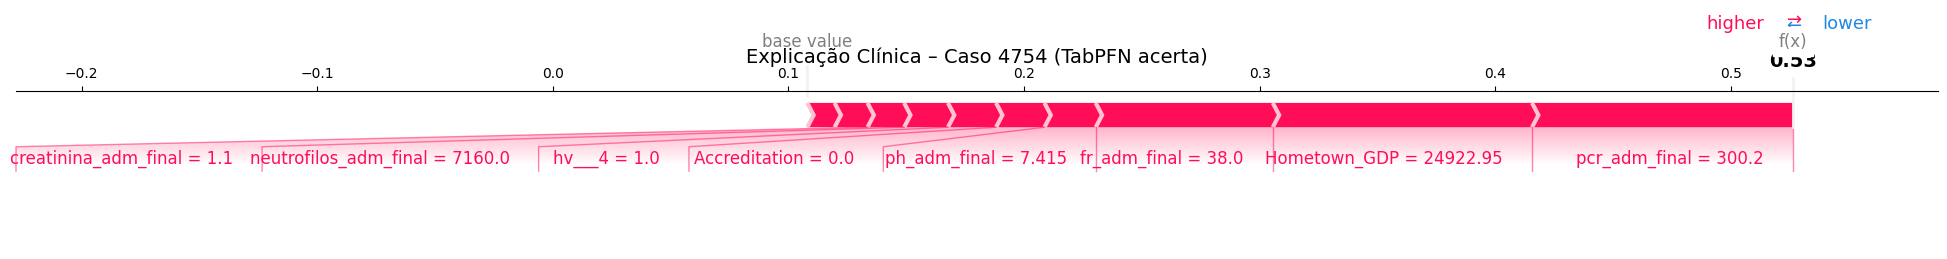

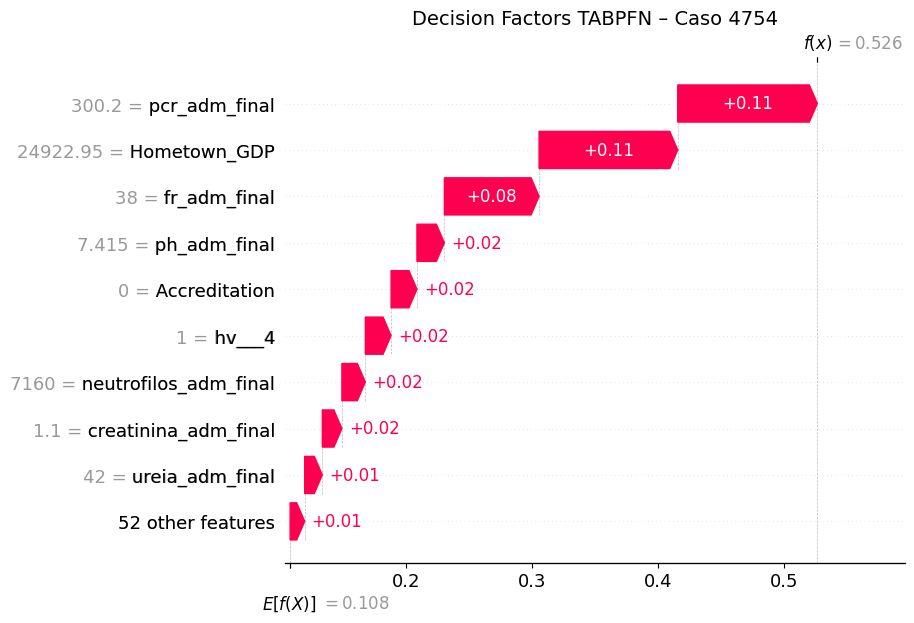

true_label é 1.0 tab_pred é 1.0 e xgb_pred é 0


<Figure size 2000x600 with 0 Axes>

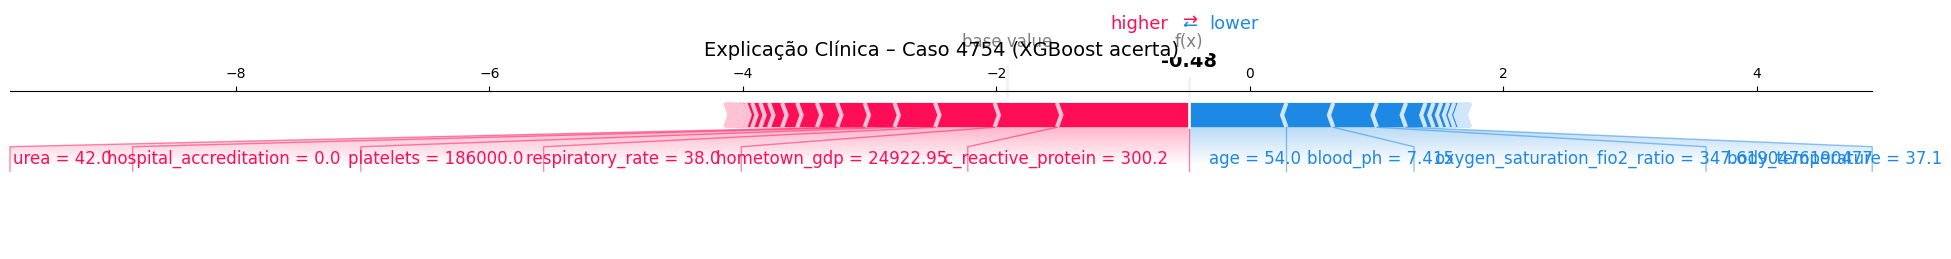

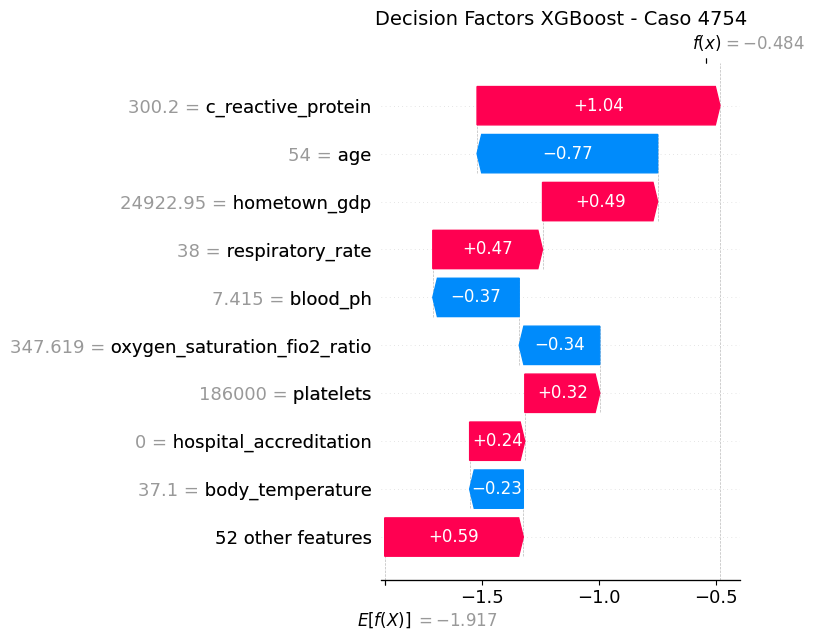

Gerando narrativa do Grupo A (Somente SHAP) com Ollama...
Gerando narrativa do Grupo B (SHAP + Predição) com Ollama...
Narrativas geradas para indice 4754

Gerando resposta para indice: 4774

--- Analisando Caso Clínico ---
Index original: 4774
Real: 1.0 | TabPFN: 1.0 (correto) | XGBoost: 0 (errado)
Classe de interesse para explicação: 1

--- DEBUG SHAP ---
base_value: 0.10800807043211534
shap_values shape: (61,)
row_data shape: (61,)
-----------------



<Figure size 2800x700 with 0 Axes>

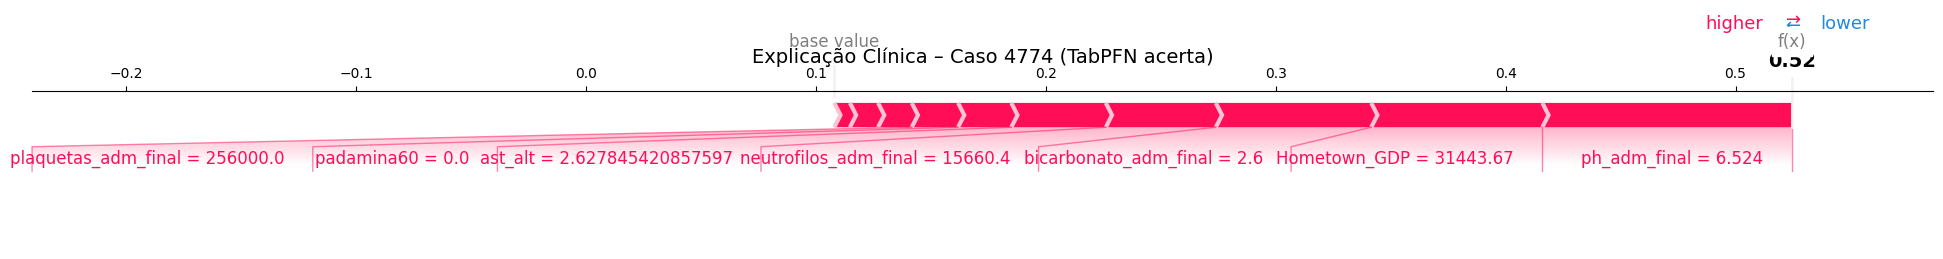

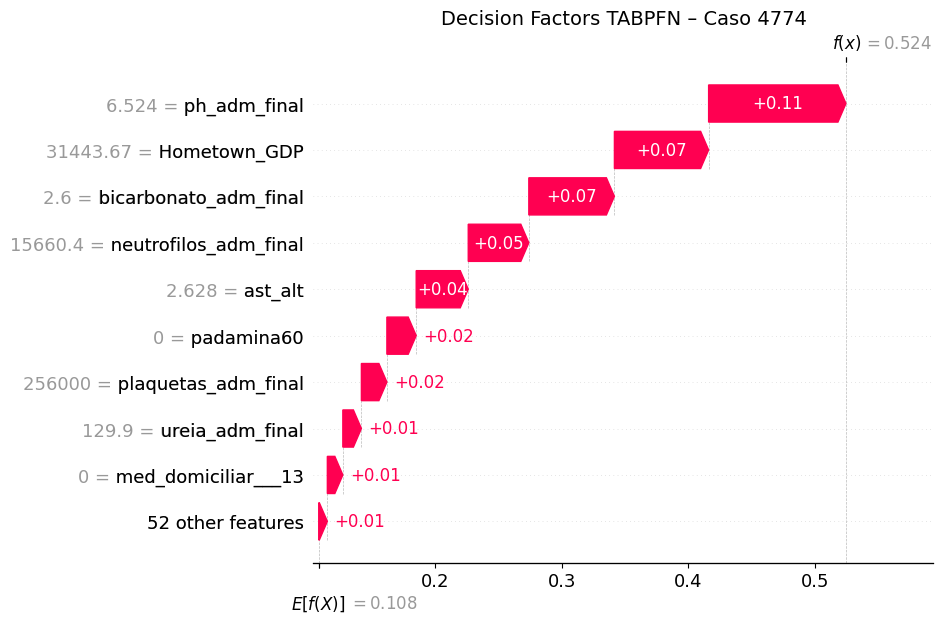

true_label é 1.0 tab_pred é 1.0 e xgb_pred é 0


<Figure size 2000x600 with 0 Axes>

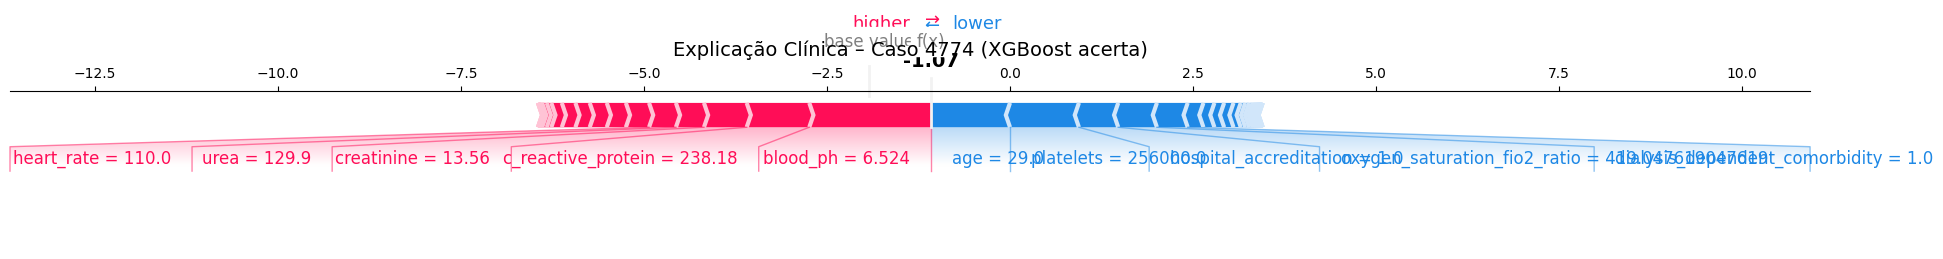

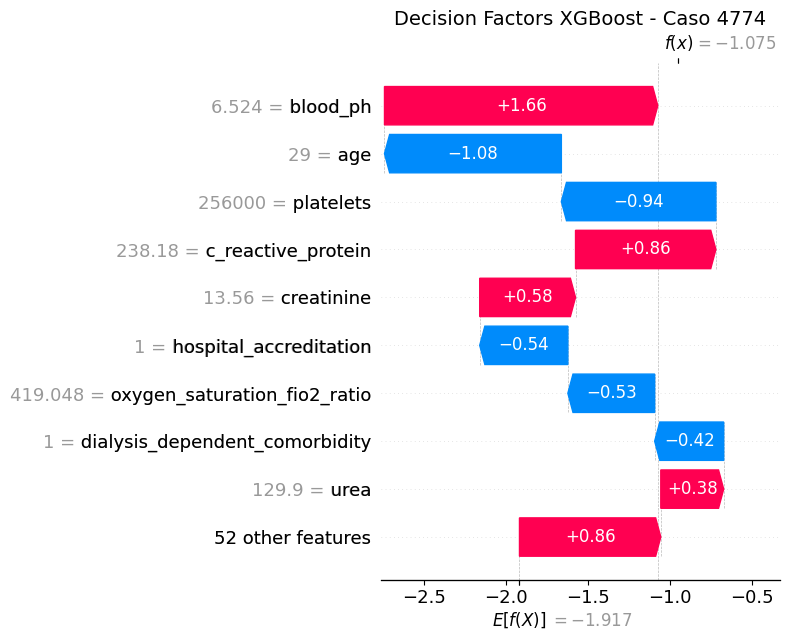

Gerando narrativa do Grupo A (Somente SHAP) com Ollama...
Gerando narrativa do Grupo B (SHAP + Predição) com Ollama...
Narrativas geradas para indice 4774

Gerando resposta para indice: 4824

--- Analisando Caso Clínico ---
Index original: 4824
Real: 1.0 | TabPFN: 1.0 (correto) | XGBoost: 0 (errado)
Classe de interesse para explicação: 1

--- DEBUG SHAP ---
base_value: 0.10800807043211534
shap_values shape: (61,)
row_data shape: (61,)
-----------------



<Figure size 2800x700 with 0 Axes>

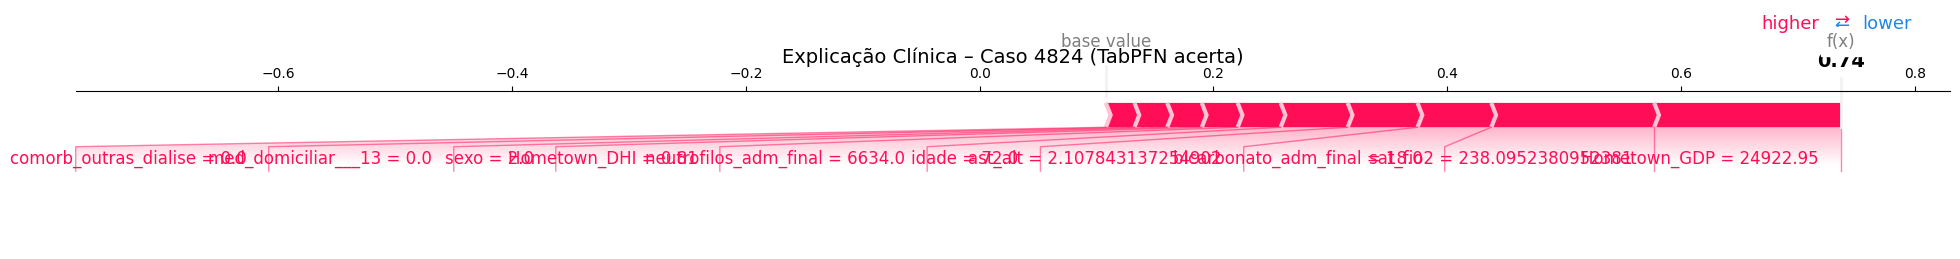

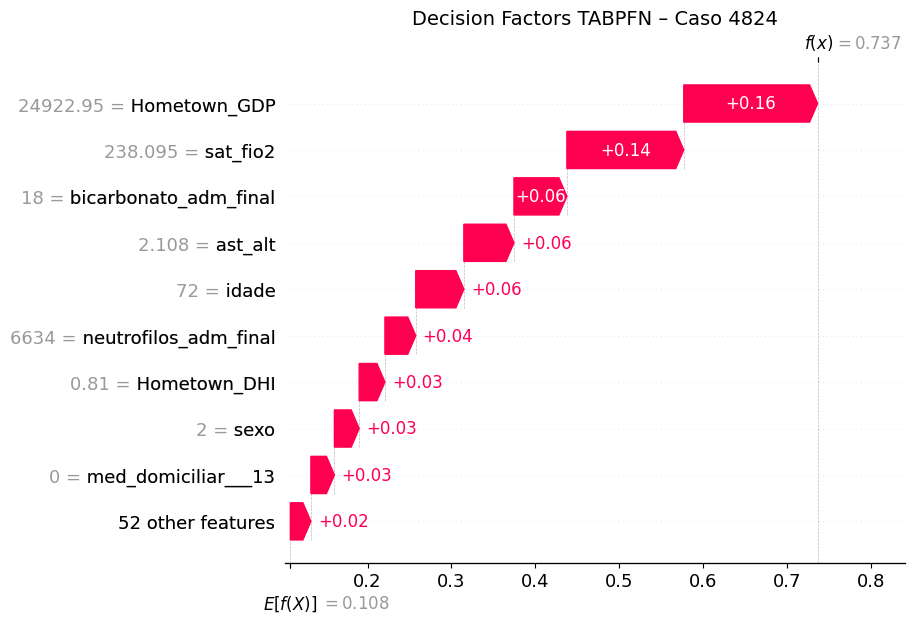

true_label é 1.0 tab_pred é 1.0 e xgb_pred é 0


<Figure size 2000x600 with 0 Axes>

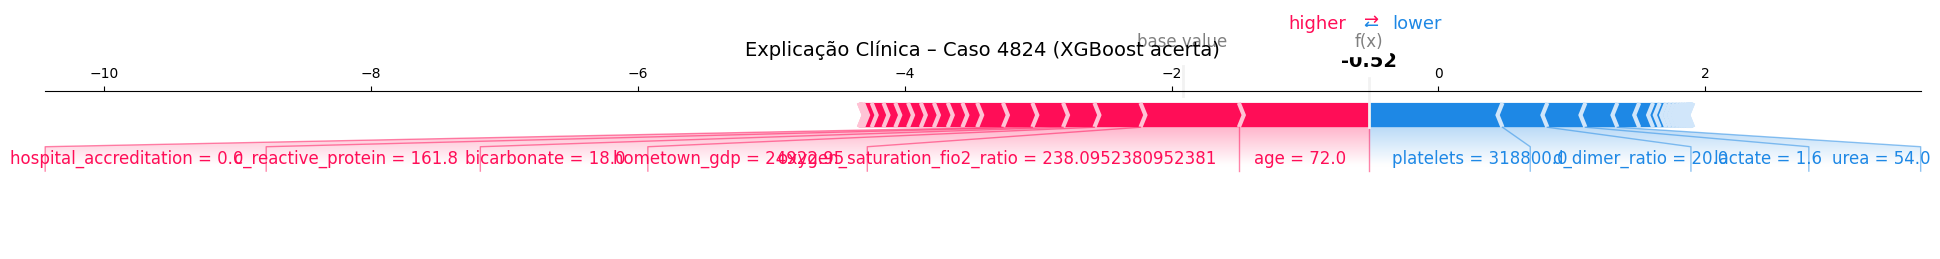

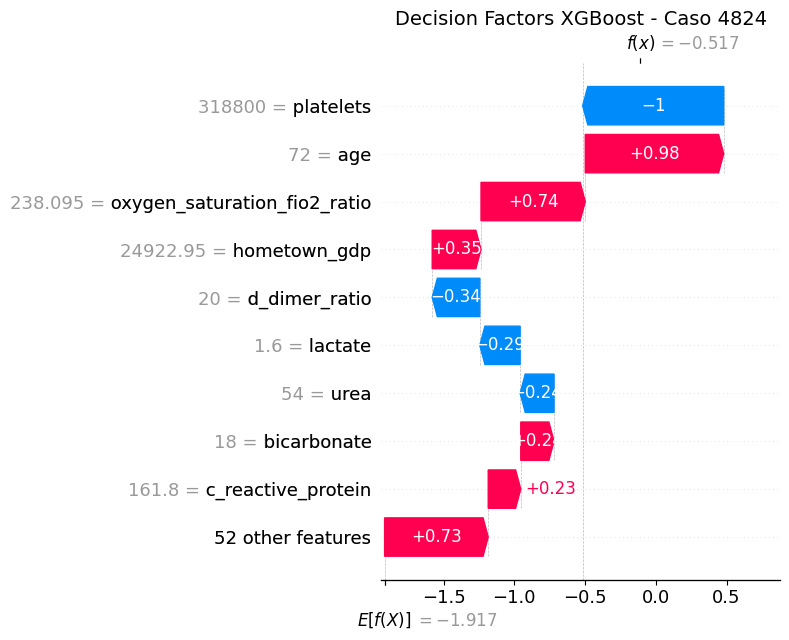

Gerando narrativa do Grupo A (Somente SHAP) com Ollama...
Gerando narrativa do Grupo B (SHAP + Predição) com Ollama...
Narrativas geradas para indice 4824

Respostas salvo em: respostas/casos_respostas.json


In [23]:
indices_tab_right = casos.loc[(casos['true_label'] == 1) & (casos['true_label'] == casos['tab_pred']), 'original_index'].tolist()
print(f"len casos divergentes tab acertou obito: {len(indices_tab_right)}\n" 
        f"{indices_tab_right}")

lista_respostas = []
for idx in indices_tab_right[0:3]:
    lista_respostas.append(gerar_resposta_caso(idx))

try:
    respostas_dir = Path("respostas")
    respostas_dir.mkdir(parents=True, exist_ok=True)
    arquivo_resposta = respostas_dir / (
        f"casos_respostas.json"
    )
    with arquivo_resposta.open("w", encoding="utf-8") as f:
        json.dump(
            lista_respostas,
            f,
            ensure_ascii=False,
            indent=4,
        )
    print(f"Respostas salvo em: {arquivo_resposta}")
except (OSError, TypeError, ValueError) as e:
    print(f"Erro ao salvar a respostas: {e}")